#### 1. Set up the reaction graph from DFT data 

In [25]:
from arcs.generate import GraphGenerator

gg = GraphGenerator()
graph = gg.from_file(
    filename='../src/arcs/data/quantum_data.json.gz',
    temperature=248,
    pressure=20,
    max_reaction_length=4,
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [12]:
gg.quantum_dict_metadata

{'code': 'PSI4', 'version': '1.9.1', 'method': 'ccsd', 'basis': 'cc-pvdz'}

In [ ]:
import pandas as pd 
pd.Series(gg.compound_reference) # these are the compounds present in the graph

H2O                                        O
NH3                                        N
O3                                [O-][O+]=O
C6H6                                c1ccccc1
CH3COOH                              CC(=O)O
CH3_2_CHCH2NH2                        CC(C)N
N2O2                                N(=O)N=O
CH4                                        C
HCOOH                                   OC=O
O2                                       O=O
N2O                              [N-]=[N+]=O
H2SO4                            OS(=O)(=O)O
CH3CHO                                  CC=O
C2H5NH2                                  CCN
H2S                                        S
HNO3                           O[N+](=O)[O-]
N2O4              [N+](=O)([N+](=O)[O-])[O-]
CH3_C6H5                           Cc1ccccc1
HCN                                      C#N
CH3NH2                                    CN
H2SO3                                OS(=O)O
H2CO3                                O=C(O)O
HNO2      

#### 2. Sample the `graph`

In [21]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':5,'H2S':0,'NO2':20}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=10,nsamples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [22]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

1 H2 + 1 NO2 = 1 H2O + 1 NO          360
1 H2O2 + 1 NO = 1 H2O + 1 NO2        230
1 H2O + 1 NO3 = 1 NO2 + 1 H2O2       130
1 N2O2 + 1 O2 = 2 NO2                110
1 H2O + 2 NO2 = 1 HNO3 + 1 HNO2      110
2 H2O2 = 2 H2O + 1 O2                100
3 H2 + 2 NO2 = 3 H2O + 1 N2O         100
1 H2O + 1 NO3 + 1 NO2 = 2 HNO3        90
1 NO + 1 SO3 = 1 NO2 + 1 SO2          80
2 HNO2 = 1 H2O + 1 NO2 + 1 NO         80
2 O2 + 1 N2 = 2 NO2                   60
1 H2SO3 = 1 H2O + 1 SO2               60
1 O2 + 2 NO = 2 NO2                   60
1 NO3 + 1 H2 = 1 H2O + 1 NO2          50
1 H2 + 1 SO3 = 1 H2O + 1 SO2          50
4 H2 + 2 NO2 = 4 H2O + 1 N2           50
1 O2 + 2 SO2 = 2 SO3                  40
2 NO2 + 2 SO2 + 1 H2O2 = 2 NOHSO4     40
2 HNO3 + 1 SO2 = 1 H2SO4 + 2 NO2      20
1 H2O + 3 NO2 = 2 HNO3 + 1 NO         20
dtype: int64

#### 4. generate mean concentrations and differences

In [23]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
average_data = average_data[average_data["mean"].round(3) !=0]

print(average_data.round(3).to_string())

        initial    mean   diff    sem    std     var
NO2        20.0  17.572 -2.428  0.137  6.213  38.605
H2O        30.0  28.897 -1.103  0.065  2.930   8.584
SO2         5.0   4.610 -0.390  0.028  1.287   1.655
O2         10.0   9.857 -0.143  0.014  0.657   0.431
N2O         0.0   0.007  0.007  0.002  0.101   0.010
N2          0.0   0.012  0.012  0.003  0.123   0.015
N2O4        0.0   0.024  0.024  0.008  0.348   0.121
H2SO4       0.0   0.024  0.024  0.008  0.348   0.121
NOHSO4      0.0   0.146  0.146  0.019  0.841   0.707
NO          0.0   0.184  0.184  0.022  0.999   0.998
SO3         0.0   0.220  0.220  0.021  0.954   0.909
HNO2        0.0   0.783  0.783  0.055  2.516   6.328
HNO3        0.0   1.229  1.229  0.073  3.318  11.010


#### 5. Plot 

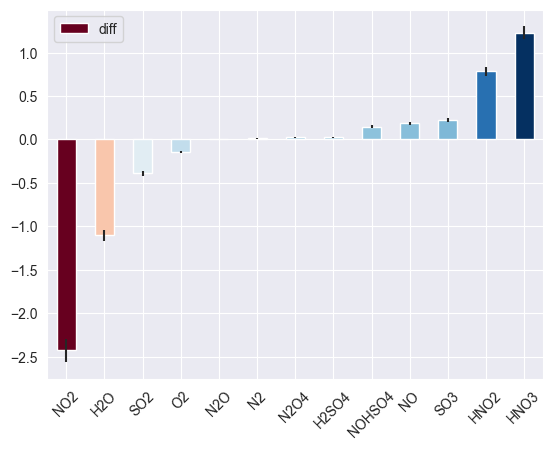

In [24]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = plt.get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors,rot=45)

plt.show()

#### 5. generate a `pyvis` graph 

In [ ]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

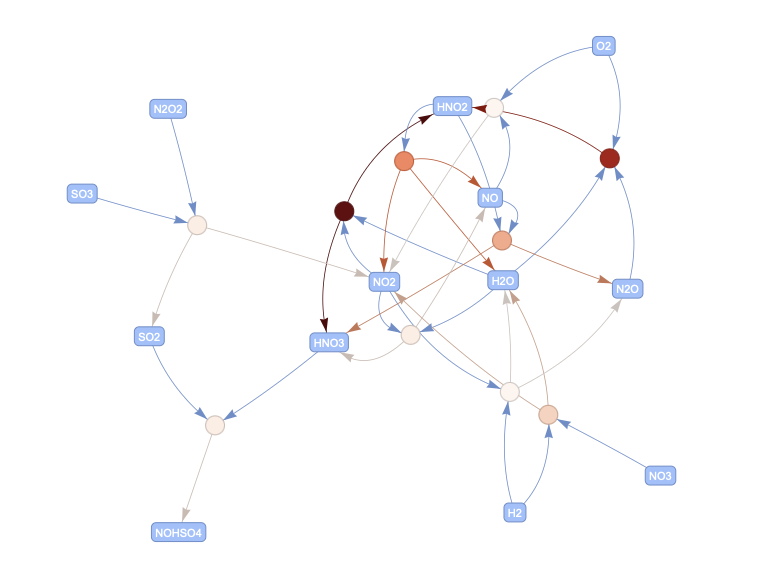

In [ ]:
! open example_pyvis_graph.html